#모델 오류 확인용 inpynb

In [1]:
import torch
from convNext import convnext_base
from BN_conv import bn_conv
from de_convNext import de_convnext_base

from torchvision import transforms # 전처리 모듈
from torchvision.datasets import ImageFolder
import torch.utils.data as data
from torch.utils.data import DataLoader # 학습 및 배치로 모델에 넣어주기 위한 모듈

# ----

import numpy as np
import matplotlib.pyplot as plt # 시각화를 위한 모듈

import time
import natsort
import os

folder_list = os.listdir("./data/")
item_list = natsort.natsorted(folder_list)

print("다음 데이터셋들이 학습됩니다 : ", item_list)



다음 데이터셋들이 학습됩니다 :  ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [2]:
FILE_PATH = "/data/hazelnut/train"
print(FILE_PATH)

image_size = 256
epoch = 200
batch_size = 16
lr = 0.001

/data/hazelnut/train


In [3]:
def get_data_transforms(size, isize):
    mean_train = [0.485, 0.456, 0.406]
    std_train = [0.229, 0.224, 0.225]
    data_transforms = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.CenterCrop(isize),
        transforms.Normalize(mean=mean_train,std=std_train)
        ]
        )
    
    return data_transforms


# Compose는 여러 transform을 적용할 수 있도록 묶어주는 역할
train_data = ImageFolder("./data/hazelnut/train", transform = get_data_transforms(image_size,image_size))
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

print("train_imgs len : ", len(train_data)) #imagefolder객체

train_imgs len :  391


#이미지 출력 확인

/tmp/ipykernel_5221/75358579.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  plt.imshow(image.T) # imshow는 (m, n, 3)의 형태를 받으므로 Transpose
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..1.4611696].


torch.Size([3, 256, 256])
0


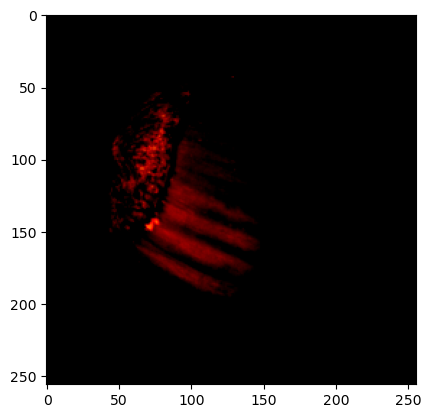

In [4]:
image, label = train_data[0]
print(image.shape)
print(label)

plt.imshow(image.T) # imshow는 (m, n, 3)의 형태를 받으므로 Transpose


In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

encoder = convnext_base(weights='ConvNeXt_Base_Weights.IMAGENET1K_V1',pretrained=True)
encoder = encoder.to(device)
encoder.eval()

bn = bn_conv()
bn = bn.to(device)
bn.train()

decoder = de_convnext_base()
decoder = decoder.to(device)
decoder.train()


de_ConvNeXt(
  (features): Sequential(
    (0): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(1024, 1024, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=1024)
          (1): Permute()
          (2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=1024, out_features=4096, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=4096, out_features=1024, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(1024, 1024, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=1024)
          (1): Permute()
          (2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=1024, out_features=4096, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=4096, out_features=1024, bia

#encoder 작동 테스드

In [6]:
with torch.no_grad():
    for images, labels in train_dataloader : 
        images = images.to(device)
        labels = labels.to(device)
        output_1 = encoder(images)
        output_2 = bn(output_1)
        output_3 = decoder(output_2)


encoder feature_stem size : torch.Size([16, 128, 64, 64])
encoder feature_a size : torch.Size([16, 128, 64, 64])
encoder feature_b size : torch.Size([16, 256, 32, 32])
encoder feature_c size : torch.Size([16, 512, 16, 16])
decoder feature_a : torch.Size([16, 512, 16, 16])
decoder feature_b : torch.Size([16, 256, 32, 32])
decoder feature_c : torch.Size([16, 128, 64, 64])
encoder feature_stem size : torch.Size([16, 128, 64, 64])
encoder feature_a size : torch.Size([16, 128, 64, 64])
encoder feature_b size : torch.Size([16, 256, 32, 32])
encoder feature_c size : torch.Size([16, 512, 16, 16])
decoder feature_a : torch.Size([16, 512, 16, 16])
decoder feature_b : torch.Size([16, 256, 32, 32])
decoder feature_c : torch.Size([16, 128, 64, 64])
encoder feature_stem size : torch.Size([16, 128, 64, 64])
encoder feature_a size : torch.Size([16, 128, 64, 64])
encoder feature_b size : torch.Size([16, 256, 32, 32])
encoder feature_c size : torch.Size([16, 512, 16, 16])
decoder feature_a : torch.Size(

##train

In [7]:
import time
import natsort
import os

# ----

import torch
from convNext import convnext_base
from BN_conv import bn_conv
from de_convNext import de_convnext_base

from torchvision import transforms # 전처리 모듈
from torchvision.datasets import ImageFolder
import torch.utils.data as data
from torch.utils.data import DataLoader # 학습 및 배치로 모델에 넣어주기 위한 모듈

# ----

import numpy as np
import matplotlib.pyplot as plt # 시각화를 위한 모듈
import random


folder_list = os.listdir("./data/")
item_list = natsort.natsorted(folder_list)

print("다음 데이터셋들이 학습됩니다 : ", item_list)

다음 데이터셋들이 학습됩니다 :  ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [8]:
FILE_PATH = "/data/hazelnut/train"
print(FILE_PATH)

image_size = 128
epochs = 10
batch_size = 4
learning_rate = 0.001

/data/hazelnut/train


In [9]:
def loss_fucntion(a, b):
    #mse_loss = torch.nn.MSELoss()
    cos_loss = torch.nn.CosineSimilarity()
    loss = 0
    for item in range(len(a)):
        #print(a[item].shape)
        #print(b[item].shape)
        #loss += 0.1*mse_loss(a[item], b[item])
        loss += torch.mean(1-cos_loss(a[item].reshape(a[item].shape[0],-1),
                                      b[item].reshape(b[item].shape[0],-1)))
    return loss


def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [10]:
def train(_class_):
        
    data_transform = get_data_transforms(image_size, image_size)
    
    train_path = './data/' + _class_ + '/train'
    ckp_path = './checkpoints/' + 'wres50_'+_class_+'.pth'
    
    train_data = ImageFolder(root=train_path, transform= data_transform)
    train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    encoder = convnext_base(weights='ConvNeXt_Base_Weights.IMAGENET1K_V1',pretrained=True)
    encoder = encoder.to(device)
    encoder.eval()
    
    for p in encoder.parameters():
        p.requires_grad_(False)

    bn = bn_conv()
    bn = bn.to(device)
    bn.train()

    decoder = de_convnext_base()
    decoder = decoder.to(device)
    decoder.train()

    optimizer = torch.optim.Adam(list(decoder.parameters())+list(bn.parameters()), lr=learning_rate, betas=(0.5,0.999))


    for epoch in range(epochs):
        start = time.time() 
        
        loss_list = []
        for img, label in train_dataloader:
            img = img.to(device)

            with torch.no_grad():
                inputs = encoder(img)
                
            outputs = decoder(bn(inputs))
            loss = loss_fucntion(inputs, outputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_list.append(loss.item())
        print('epoch [{}/{}], loss:{:.4f}'.format(epoch + 1, epochs, np.mean(loss_list)))
        print("time :",time.time() - start)  # 현재시각 - 시작시간 = 실행 시간
        
        if (epoch + 1) % 10 == 0:
            torch.save({'bn': bn.state_dict(),'decoder': decoder.state_dict()}, ckp_path)
            
    return loss

In [11]:
setup_seed(111)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [12]:
print(item_list)

['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [13]:
#학습

train_class = 'hazelnut'

start_class = time.time()  # 시작 시간 저장
train(train_class)
print("time :",time.time() - start_class)  # 현재시각 - 시작시간 = 실행 시간

encoder feature_stem size : torch.Size([4, 128, 32, 32])
encoder feature_a size : torch.Size([4, 128, 32, 32])
encoder feature_b size : torch.Size([4, 256, 16, 16])
encoder feature_c size : torch.Size([4, 512, 8, 8])
decoder feature_a : torch.Size([4, 512, 8, 8])
decoder feature_b : torch.Size([4, 256, 16, 16])
decoder feature_c : torch.Size([4, 128, 32, 32])
encoder feature_stem size : torch.Size([4, 128, 32, 32])
encoder feature_a size : torch.Size([4, 128, 32, 32])
encoder feature_b size : torch.Size([4, 256, 16, 16])
encoder feature_c size : torch.Size([4, 512, 8, 8])
decoder feature_a : torch.Size([4, 512, 8, 8])
decoder feature_b : torch.Size([4, 256, 16, 16])
decoder feature_c : torch.Size([4, 128, 32, 32])
encoder feature_stem size : torch.Size([4, 128, 32, 32])
encoder feature_a size : torch.Size([4, 128, 32, 32])
encoder feature_b size : torch.Size([4, 256, 16, 16])
encoder feature_c size : torch.Size([4, 512, 8, 8])
decoder feature_a : torch.Size([4, 512, 8, 8])
decoder feat

KeyboardInterrupt: 